In [26]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde, norm
from empiricaldist import Pmf
from utils import decorate

sns.set_style('darkgrid')

## 9.2 The Prior

In [2]:
def read_data(filename):
    """Read the showcase price data."""
    df = pd.read_csv(filename, index_col=0, skiprows=[1])
    return df.dropna().transpose()

In [4]:
df2011 = read_data('./data/showcases.2011.csv')
df2012 = read_data('./data/showcases.2012.csv')

df = pd.concat([df2011, df2012], ignore_index=True)
df.head(3)

,Showcase 1,Showcase 2,Bid 1,Bid 2,Difference 1,Difference 2
0,50969.0,45429.0,42000.0,34000.0,8969.0,11429.0
1,21901.0,34061.0,14000.0,59900.0,7901.0,-25839.0
2,32815.0,53186.0,32000.0,45000.0,815.0,8186.0


## 9.3 Kernel Density Estimation

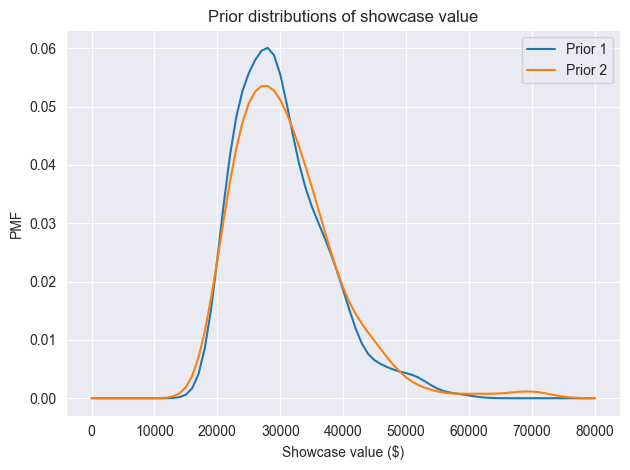

In [11]:
def kde_from_sample(sample, qs):
    """Make a kernel density estimate from a sample."""
    kde = gaussian_kde(sample)
    ps = kde(qs)
    pmf = Pmf(ps, qs)
    pmf.normalize()
    return pmf


def decorate_value(title=''):
    decorate(
        xlabel='Showcase value ($)',
        ylabel='PMF',
        title=title
    )
    

qs = np.linspace(0, 80000, 81)
prior1 = kde_from_sample(df['Showcase 1'], qs)
prior2 = kde_from_sample(df['Showcase 2'], qs)

prior1.plot(label='Prior 1')
prior2.plot(label='Prior 2')

decorate_value('Prior distributions of showcase value')

## 9.4 Distribution of Error

In [ ]:
sample_diff1 = df['Bid 1'] - df['Showcase 1']

mean_diff1 = sample_diff1.mean()
std_diff1 = sample_diff1.std()

print(mean_diff1, std_diff1)
error_dist1 = norm(0, std_diff1)

-4116.3961661341855 6899.909806377117


In [17]:
sample_diff2 = df['Bid 2'] - df['Showcase 2']

mean_diff2 = sample_diff2.mean()
std_diff2 = sample_diff2.std()

print(mean_diff2, std_diff2)
error_dist2 = norm(0, std_diff2)

-3675.891373801917 6886.260711323408


## 9.5 Update

(30299.488817891375, 26192.024002392536)

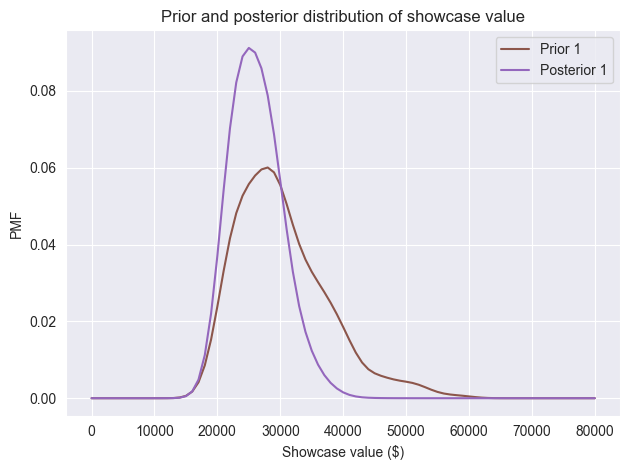

In [18]:
guess1 = 23000
error1 = guess1 - prior1.qs
likelihood1 = error_dist1.pdf(error1)

posterior1 = prior1 * likelihood1
posterior1.normalize()

prior1.plot(color='C5', label='Prior 1')
posterior1.plot(color='C4', label='Posterior 1')
decorate_value('Prior and posterior distribution of showcase value')

prior1.mean(), posterior1.mean()

(31047.623719122505, 34305.20161642469)

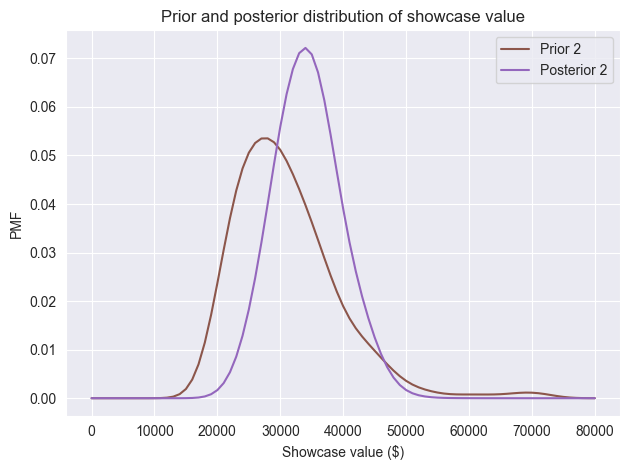

In [19]:
guess2 = 38000
error2 = guess2 - prior2.qs
likelihood2 = error_dist2.pdf(error2)

posterior2 = prior2 * likelihood2
posterior2.normalize()

prior2.plot(color='C5', label='Prior 2')
posterior2.plot(color='C4', label='Posterior 2')
decorate_value('Prior and posterior distribution of showcase value')

prior2.mean(), posterior2.mean()

## 9.6. Probability of Winning

In [30]:
def prob_overbid(sample_diff):
    """Compute the probability of an overbid."""
    return np.mean(sample_diff > 0)


print(f"Probability of player 2 overbidding: {prob_overbid(sample_diff2)}")

Probability of player 2 overbidding: 0.29073482428115016


In [29]:
def prob_worse_than(given_diff, sample_diff):
    """Probability opponent diff is worse than given diff."""
    return np.mean(sample_diff < given_diff)


print(f"Probability of player 2 diff worse than -5000: {prob_worse_than(-5000, sample_diff2)}")
print(f"Probability of player 2 diff worse than -10000: {prob_worse_than(-10000, sample_diff2)}")

Probability of player 2 diff worse than -5000: 0.38338658146964855
Probability of player 2 diff worse than -10000: 0.14376996805111822


In [24]:
def compute_prob_win(given_diff, opponent_sample_diff):
    """Probability of winning for a given diff."""
    # if you overbid you lose
    if given_diff > 0:
        return 0
    
    # if the opponent overbids, you win
    prob_opponent_overbid = prob_overbid(opponent_sample_diff)
    
    # or of their bid is worse than yours, you win
    prob_opponent_worse = prob_worse_than(given_diff, opponent_sample_diff)
    
    # p1 and p2 are mutually exclusive, so we can add them
    return prob_opponent_overbid + prob_opponent_worse


prob_win1 = compute_prob_win(-5000, sample_diff2)
print(f"Probability of player 1 winning with a diff of -5000: {prob_win1:.2%}")

Probability of player 1 winning with a diff of -5000: 67.41%


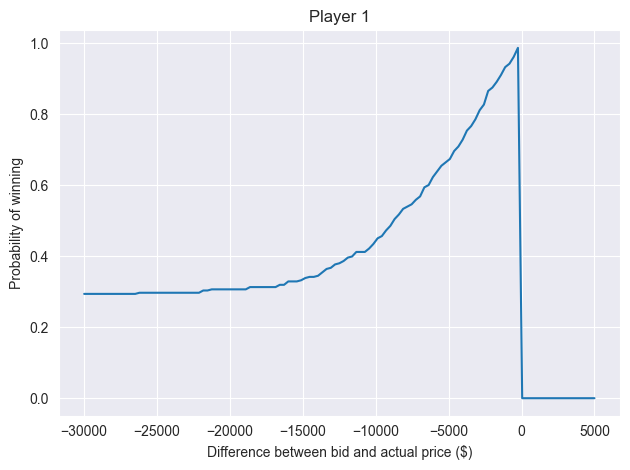

In [ ]:
xs = np.linspace(-30000, 5000, 121)
ys = [compute_prob_win(x, sample_diff2) for x in xs]

plt.plot(xs, ys)
decorate(
    xlabel='Difference between bid and actual price ($)',
    ylabel='Probability of winning',
    title='Player 1'
)

In [31]:
print(f"Probability of player 1 overbidding: {prob_overbid(sample_diff1)}")
print(f"Probability of player 1 diff worse than -5000: {prob_worse_than(-5000, sample_diff1)}")
print(f"Probability of player 2 winning with -5000 diff: {compute_prob_win(-5000, sample_diff1)}")

Probability of player 1 overbidding: 0.24600638977635783
Probability of player 1 diff worse than -5000: 0.3993610223642173
Probability of player 2 winning with -5000 diff: 0.6453674121405751


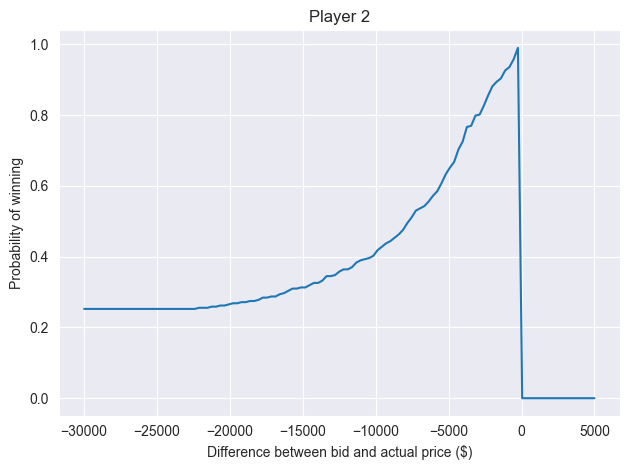

In [32]:
xs = np.linspace(-30000, 5000, 121)
ys = [compute_prob_win(x, sample_diff1) for x in xs]

plt.plot(xs, ys)
decorate(
    xlabel='Difference between bid and actual price ($)',
    ylabel='Probability of winning',
    title='Player 2'
)